First 5 rows:
         CRIM         ZN      INDUS  CHAS       NOX        RM        AGE  \
0  49.393215  86.231855   8.626335     1  0.617245  5.683937  36.916120   
1  64.367043   4.869030  13.701109     0  0.581631  7.924406  63.250897   
2  54.248704  25.364252   0.628502     1  0.755670  8.543270  51.462554   
3  49.039486  44.613551  12.348465     1  0.406921  5.887842  13.772485   
4  38.128932  10.462789  14.683759     1  0.402703  7.124111  64.906960   

         DIS  RAD         TAX    PTRATIO           B      LSTAT       MEDV  
0  10.759186    5  584.367690  13.602704    6.548062  36.888778  38.022799  
1   5.863423   23  634.681938  15.389710  224.700092  33.649006   7.844217  
2   1.021584   19  325.269794  17.133073   84.482488  30.034060  22.057450  
3   4.138696    7  509.131841  13.385143  248.765036  19.871959  20.409509  
4   9.955746    2  632.029734  13.966468  133.879706  35.573335  34.106969  

Shape: (506, 14)

Missing Values:
 CRIM       0
ZN         0
INDUS     

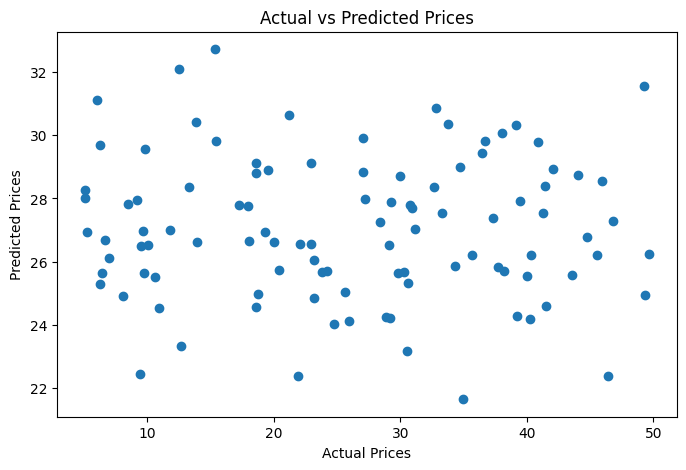

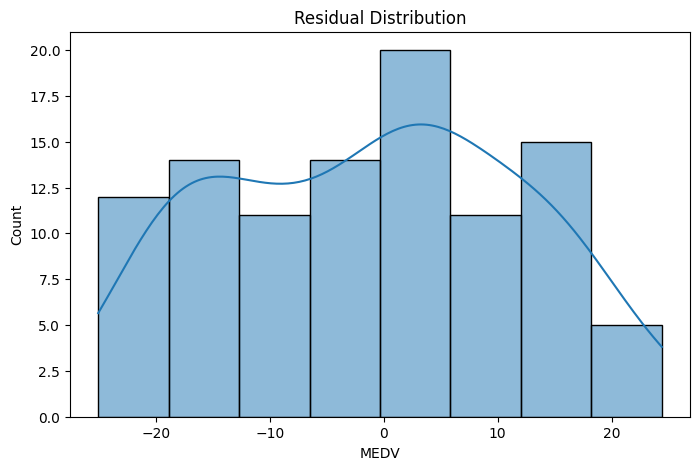


Feature Coefficients:
          Coefficient
CRIM        0.016267
ZN          0.039205
INDUS       0.001115
CHAS       -0.027306
NOX         0.353039
RM          0.189184
AGE         0.031092
DIS         0.332066
RAD         0.059318
TAX        -0.001785
PTRATIO     0.079727
B          -0.007791
LSTAT      -0.004018


In [2]:
# -----------------------------------
# IMPORT LIBRARIES
# -----------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# -----------------------------------
# LOAD DATASET
# -----------------------------------
df = pd.read_csv('boston_housing.csv')

print("First 5 rows:\n", df.head())
print("\nShape:", df.shape)

# -----------------------------------
# DATA PREPROCESSING
# -----------------------------------
print("\nMissing Values:\n", df.isnull().sum())

# Fill missing values if any
df.fillna(df.mean(), inplace=True)

# -----------------------------------
# FEATURE & TARGET SPLIT
# -----------------------------------
X = df.drop('MEDV', axis=1)   # Features
y = df['MEDV']                # Target (House Price)

# -----------------------------------
# TRAIN-TEST SPLIT
# -----------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

# -----------------------------------
# MODEL TRAINING (LINEAR REGRESSION)
# -----------------------------------
model = LinearRegression()
model.fit(X_train, y_train)

# -----------------------------------
# PREDICTION
# -----------------------------------
y_pred = model.predict(X_test)

# -----------------------------------
# MODEL EVALUATION
# -----------------------------------
print("\nModel Evaluation:")

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

# -----------------------------------
# VISUALIZATION
# -----------------------------------

# Actual vs Predicted
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()

# Residual Plot
residuals = y_test - y_pred

plt.figure(figsize=(8,5))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

# MODEL COEFFICIENTS
coefficients = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
print("\nFeature Coefficients:\n", coefficients)